# Enhanced Virtual Try-On (VITON-Style)
## MSDS Computer Vision 462 – Final Project

| | |
|---|---|
| **Team** | Joyati · Biraj Mishra · Murughanandam S. |
| **Course** | MSDS COMPUTERVISION 462 |
| **Date** | Spring 2026 |

---

## Abstract

Virtual try-on (VTON) is the task of synthesising a photo-realistic image of a
target person wearing a specified garment without any physical fitting.  It has
direct commercial applications in e-commerce, fashion recommendation, and
augmented reality.

This notebook presents a complete, end-to-end VTON pipeline built on the
publicly available VITON-HD dataset (Zalando Research, ~11 k training pairs).
The pipeline includes:

1. **Exploratory Data Analysis** – image statistics, semantic parse-map label
   frequencies, OpenPose keypoint analysis, cloth-mask coverage, and colour
   distributions.
2. **Data Pipeline** – a PyTorch `Dataset` that loads all five modalities
   (person image, garment image, garment mask, agnostic image, parse map) and
   applies geometry-aware cloth warping + augmentation on-the-fly.
3. **Classical Baseline** – a parse-map-guided bounding-box warp with Gaussian
   feathering, implemented entirely in NumPy / OpenCV.
4. **Deep Learning Model** – a lightweight U-Net (`LightTryOnNet`, ~1.5 M
   parameters) trained with a combined L1 + differentiable-SSIM loss,
   Adam optimiser with L2 weight decay, ReduceLROnPlateau scheduling, Dropout,
   data augmentation, gradient clipping, and early stopping.
5. **Quantitative & Qualitative Evaluation** – SSIM, PSNR, and MSE compared
   across three systems: no-change baseline, classical warp, and the DL model.
6. **Overfitting Analysis** – train/val loss gap, and a summary of all
   anti-overfitting techniques applied.

All computation runs on **CPU** with images resized to 256 x 192 for
tractability.

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Exploratory Data Analysis](#2-exploratory-data-analysis)
   - 2.1 Dataset Overview
   - 2.2 Sample Pair Visualisation
   - 2.3 Image Statistics
   - 2.4 Parse-Map Label Analysis
   - 2.5 OpenPose Keypoint Analysis
   - 2.6 Colour Distribution Analysis
   - 2.7 Cloth-Mask Coverage Analysis
3. [Data Pipeline](#3-data-pipeline)
   - 3.1 Dataset Class
   - 3.2 Data-Loader Verification
4. [Classical Baseline](#4-classical-baseline)
   - 4.1 Classical Try-On Function
   - 4.2 Qualitative Results
   - 4.3 Quantitative Metrics
5. [Deep Learning Model](#5-deep-learning-model)
   - 5.1 Architecture
   - 5.2 Loss Functions & Optimiser
   - 5.3 Training Loop (Early Stopping)
   - 5.4 Training Curves
6. [Results](#6-results)
   - 6.1 Qualitative Comparison
   - 6.2 Quantitative Comparison
7. [Overfitting Analysis](#7-overfitting-analysis)
8. [Conclusion](#8-conclusion)
9. [References](#9-references)

## 1. Setup & Imports

In [17]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
import cv2
from pathlib import Path
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.models import vgg16
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.ndimage import zoom

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Config
BASE_DIR     = Path("/Users/BirajMishra/work/playground/ms/MSDS_COMPUTERVISION_462/final-project/dataset")
TRAIN_DIR    = BASE_DIR / "train"
TEST_DIR     = BASE_DIR / "test"
IMG_H, IMG_W = 256, 192
BATCH_SIZE   = 4
NUM_EPOCHS   = 30
LR           = 1e-3
WEIGHT_DECAY = 1e-4
DEVICE       = torch.device("cpu")
TRAIN_LIMIT  = 600
VAL_LIMIT    = 100

LABEL_NAMES = {
    0: 'Background', 1: 'Hat',         2: 'Hair',
    3: 'Sunglasses', 4: 'Upper-cloth', 5: 'Dress/Upper',
    6: 'Coat',       7: 'Socks',       8: 'Pants',
    9: 'Right Shoe', 10: 'Left Shoe',  11: 'Face/Skin',
    12: 'Left Leg',  13: 'Right Leg',  14: 'Left Arm',
    15: 'Right Arm', 16: 'Bag',        17: 'Scarf',
}

print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")
print(f"Training pairs  : {TRAIN_LIMIT}  |  Validation pairs: {VAL_LIMIT}")
print(f"Image size      : {IMG_H} x {IMG_W}")

PyTorch version : 2.7.1
Device          : cpu
Training pairs  : 600  |  Validation pairs: 100
Image size      : 256 x 192


## 2. Exploratory Data Analysis

We begin with a thorough analysis of every dataset modality before building
any model.  Good EDA reveals:

- the distribution of pixel intensities and colours across persons vs. garments;
- which semantic labels dominate the parse maps (important for the warping step);
- whether OpenPose detections are reliable (high confidence = trustworthy skeleton);
- the extent of garment coverage in cloth masks.

> All EDA computations use at most **50 randomly sampled images** so that they
> complete quickly on CPU.

### 2.1 Dataset Overview

In [18]:
def load_pairs(filepath):
    pairs = []
    with open(filepath) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 2:
                pairs.append((parts[0], parts[1]))
    return pairs

train_pairs = load_pairs(BASE_DIR / "train_pairs.txt")
test_pairs  = load_pairs(BASE_DIR / "test_pairs.txt")

print(f"Train pairs : {len(train_pairs):,}")
print(f"Test pairs  : {len(test_pairs):,}")
print(f"\nSample train pair : {train_pairs[0]}")
print(f"Sample test  pair : {test_pairs[0]}")

modalities = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(TRAIN_DIR / d)])
print(f"\nAvailable modalities ({len(modalities)} total):")
for mod in modalities:
    count = len(list((TRAIN_DIR / mod).iterdir()))
    print(f"  {mod:<40s}: {count:,} files")

Train pairs : 11,647
Test pairs  : 2,032

Sample train pair : ('10224_00.jpg', '03195_00.jpg')
Sample test  pair : ('05006_00.jpg', '11001_00.jpg')

Available modalities (9 total):
  agnostic-v3.2                           : 11,647 files
  cloth                                   : 11,647 files
  cloth-mask                              : 11,647 files
  image                                   : 11,647 files
  image-densepose                         : 11,647 files
  image-parse-agnostic-v3.2               : 11,647 files
  image-parse-v3                          : 11,647 files
  openpose_img                            : 11,647 files
  openpose_json                           : 11,647 files


### 2.2 Sample Pair Visualisation

Each row shows one training pair: person image, target garment, cloth mask,
colourised parse map, and the agnostic (clothing-erased) person image.

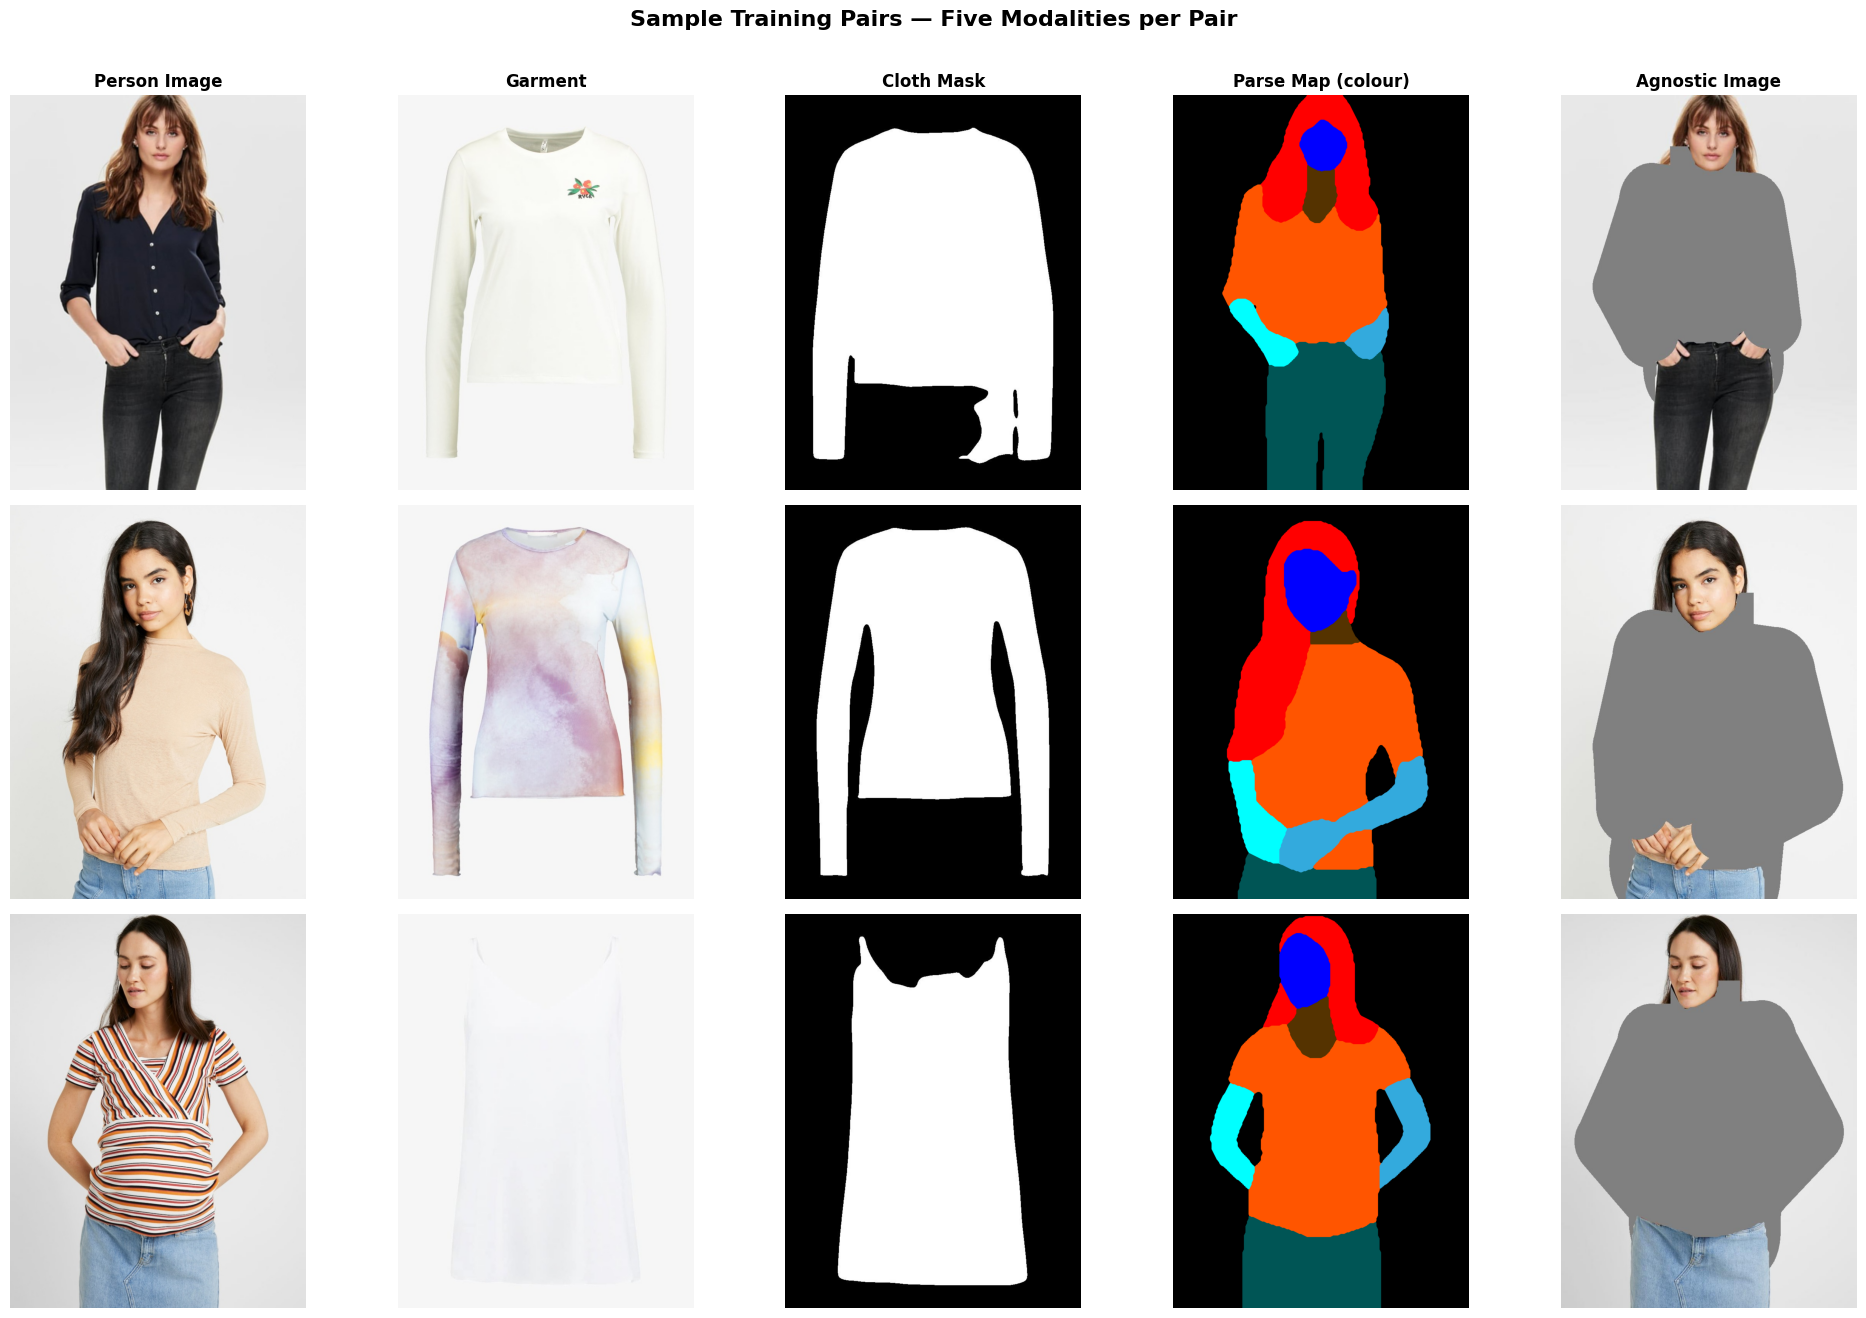

Saved: eda_sample_pairs.png


In [19]:
PARSE_COLORS = np.array([
    [0,   0,   0  ],
    [128, 0,   0  ],
    [255, 0,   0  ],
    [0,   85,  0  ],
    [170, 0,   51 ],
    [255, 85,  0  ],
    [0,   0,   85 ],
    [0,   119, 221],
    [85,  85,  0  ],
    [0,   85,  85 ],
    [85,  51,  0  ],
    [52,  86,  128],
    [0,   128, 0  ],
    [0,   0,   255],
    [51,  170, 221],
    [0,   255, 255],
    [85,  255, 170],
    [170, 255, 85 ],
], dtype=np.uint8)

def colorize_parse(parse_np):
    H, W = parse_np.shape
    rgb  = np.zeros((H, W, 3), dtype=np.uint8)
    for lbl in np.unique(parse_np):
        if lbl < len(PARSE_COLORS):
            rgb[parse_np == lbl] = PARSE_COLORS[lbl]
    return rgb

sample_indices = [0, len(train_pairs)//3, 2*len(train_pairs)//3]

fig, axes = plt.subplots(3, 5, figsize=(20, 13))
fig.suptitle("Sample Training Pairs — Five Modalities per Pair",
             fontsize=16, fontweight='bold', y=1.01)

col_titles = ["Person Image", "Garment", "Cloth Mask", "Parse Map (colour)", "Agnostic Image"]
for c, t in enumerate(col_titles):
    axes[0][c].set_title(t, fontsize=12, fontweight='bold')

for row, idx in enumerate(sample_indices):
    p_name, c_name = train_pairs[idx]
    base = p_name.replace('.jpg', '')

    person_np   = np.array(Image.open(TRAIN_DIR / "image"          / p_name))
    cloth_np    = np.array(Image.open(TRAIN_DIR / "cloth"          / c_name))
    mask_np     = np.array(Image.open(TRAIN_DIR / "cloth-mask"     / c_name).convert('L'))
    parse_np    = np.array(Image.open(TRAIN_DIR / "image-parse-v3" / (base + ".png")))
    agnostic_np = np.array(Image.open(TRAIN_DIR / "agnostic-v3.2"  / p_name))

    images = [person_np, cloth_np, mask_np, colorize_parse(parse_np), agnostic_np]
    cmaps  = [None, None, 'gray', None, None]

    for col, (img, cm) in enumerate(zip(images, cmaps)):
        axes[row][col].imshow(img, cmap=cm)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f"Pair {row+1}", fontsize=11, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("eda_sample_pairs.png", dpi=100, bbox_inches='tight')
plt.show()
print("Saved: eda_sample_pairs.png")

### 2.3 Image Statistics

We verify image dimensions and compare per-channel pixel statistics between
person images and garment images across 50 random training samples.

Person image shape : (1024, 768, 3)  (H x W x C)
Pixel dtype        : uint8

Channel-wise mean pixel value (50 samples):
  Channel         Person     Garment
  R               187.57      192.26
  G               179.96      186.17
  B               177.41      184.44


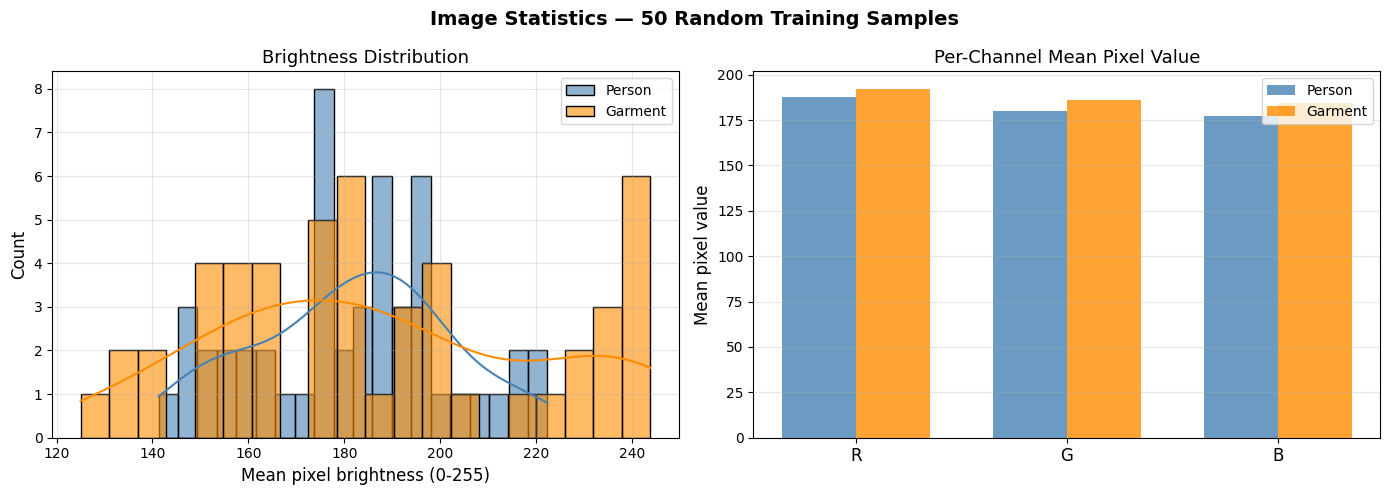

In [20]:
N_SAMPLE = 50
rng_pairs = random.sample(train_pairs, N_SAMPLE)

person_means, cloth_means = [], []
person_bright, cloth_bright = [], []

for p_name, c_name in rng_pairs:
    p_arr = np.array(Image.open(TRAIN_DIR / "image" / p_name)).astype(np.float32)
    c_arr = np.array(Image.open(TRAIN_DIR / "cloth" / c_name)).astype(np.float32)
    person_means.append(p_arr.mean(axis=(0, 1)))
    cloth_means.append(c_arr.mean(axis=(0, 1)))
    person_bright.append(p_arr.mean())
    cloth_bright.append(c_arr.mean())

person_means = np.array(person_means)
cloth_means  = np.array(cloth_means)

sample_img = np.array(Image.open(TRAIN_DIR / "image" / train_pairs[0][0]))
print(f"Person image shape : {sample_img.shape}  (H x W x C)")
print(f"Pixel dtype        : {sample_img.dtype}")

ch = ['R', 'G', 'B']
print("\nChannel-wise mean pixel value (50 samples):")
print(f"  {'Channel':10s}  {'Person':>10s}  {'Garment':>10s}")
for i, c in enumerate(ch):
    print(f"  {c:10s}  {person_means[:,i].mean():10.2f}  {cloth_means[:,i].mean():10.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Image Statistics — 50 Random Training Samples", fontsize=14, fontweight='bold')

ax = axes[0]
sns.histplot(person_bright, bins=20, color='steelblue',  label='Person',  kde=True, ax=ax, alpha=0.6)
sns.histplot(cloth_bright,  bins=20, color='darkorange', label='Garment', kde=True, ax=ax, alpha=0.6)
ax.set_xlabel("Mean pixel brightness (0-255)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Brightness Distribution", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
x  = np.arange(3)
w  = 0.35
ax2.bar(x - w/2, person_means.mean(axis=0), w, label='Person',  color='steelblue',  alpha=0.8)
ax2.bar(x + w/2, cloth_means.mean(axis=0),  w, label='Garment', color='darkorange', alpha=0.8)
ax2.set_xticks(x); ax2.set_xticklabels(['R', 'G', 'B'], fontsize=12)
ax2.set_ylabel("Mean pixel value", fontsize=12)
ax2.set_title("Per-Channel Mean Pixel Value", fontsize=13)
ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("eda_image_stats.png", dpi=100, bbox_inches='tight')
plt.show()

### 2.4 Parse-Map Label Analysis

The semantic parse map assigns a label to every pixel.  Understanding label
frequencies guides the warping strategy: we target **label 5 (upper-clothes)**
to place the new garment.

Parse-map label frequencies (% of total pixels, 50 images):
    0  Background        :  56.34%  ########################################################
    2  Hair              :   4.19%  ####
    5  Dress/Upper       :  17.10%  #################
    6  Coat              :   0.11%  
    7  Socks             :   0.59%  
    9  Right Shoe        :   8.16%  ########
   10  Left Shoe         :   1.96%  #
   12  Left Leg          :   3.33%  ###
   13  Right Leg         :   2.72%  ##
   14  Left Arm          :   2.53%  ##
   15  Right Arm         :   2.95%  ##
   16  Bag               :   0.01%  
   17  Scarf             :   0.00%  


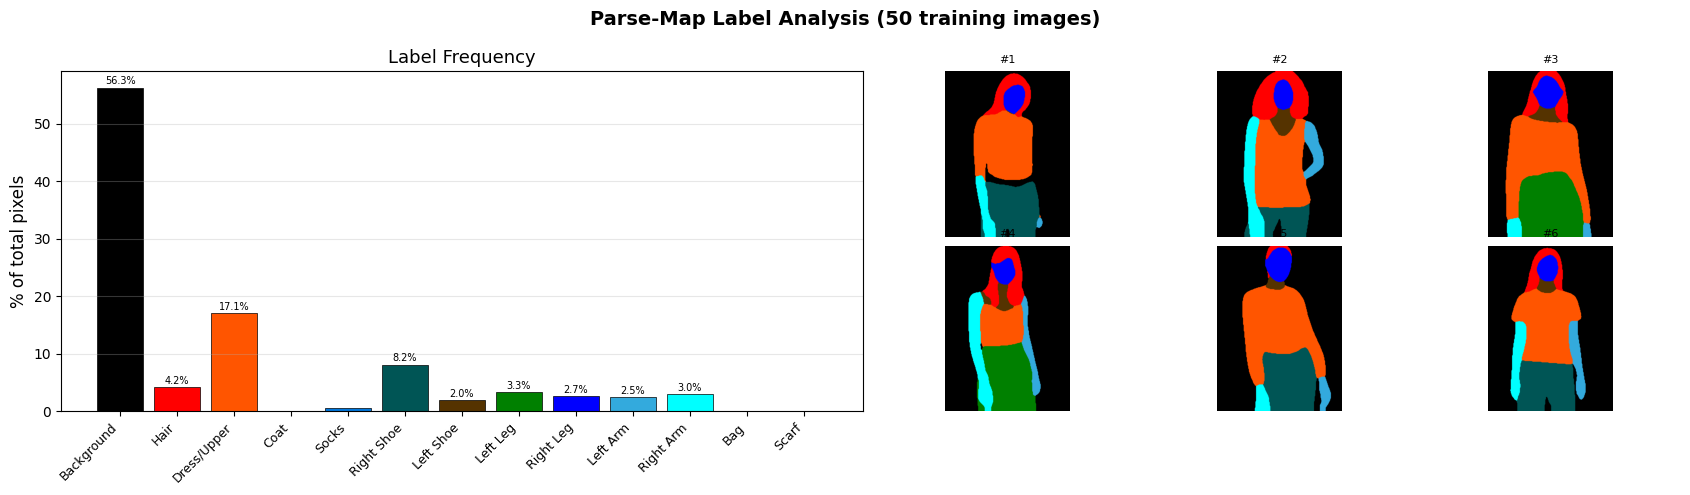

In [21]:
N_SAMPLE = 50
sample_pairs = random.sample(train_pairs, N_SAMPLE)
label_counts = Counter()
total_pixels = 0

for p_name, _ in sample_pairs:
    base = p_name.replace('.jpg', '')
    parse_arr = np.array(Image.open(TRAIN_DIR / "image-parse-v3" / (base + ".png")))
    label_counts.update(parse_arr.flatten().tolist())
    total_pixels += parse_arr.size

sorted_labels = sorted(label_counts.keys())
label_pct     = {lbl: label_counts[lbl] / total_pixels * 100 for lbl in sorted_labels}
label_str     = [LABEL_NAMES.get(lbl, f"Label {lbl}") for lbl in sorted_labels]

print("Parse-map label frequencies (% of total pixels, 50 images):")
for lbl, name, pct in zip(sorted_labels, label_str, [label_pct[l] for l in sorted_labels]):
    bar = '#' * int(pct)
    print(f"  {lbl:3d}  {name:<18s}: {pct:6.2f}%  {bar}")

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
fig.suptitle("Parse-Map Label Analysis (50 training images)", fontsize=14, fontweight='bold')

ax = axes[0]
hex_colors = [
    f"#{PARSE_COLORS[lbl][0]:02x}{PARSE_COLORS[lbl][1]:02x}{PARSE_COLORS[lbl][2]:02x}"
    if lbl < len(PARSE_COLORS) else '#888888'
    for lbl in sorted_labels
]
bars = ax.bar(label_str, [label_pct[l] for l in sorted_labels],
              color=hex_colors, edgecolor='black', linewidth=0.5)
ax.set_xticks(range(len(label_str)))
ax.set_xticklabels(label_str, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("% of total pixels", fontsize=12)
ax.set_title("Label Frequency", fontsize=13)
ax.grid(True, alpha=0.3, axis='y')
for bar, pct in zip(bars, [label_pct[l] for l in sorted_labels]):
    if pct > 1.0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{pct:.1f}%", ha='center', va='bottom', fontsize=7)

ax2 = axes[1]
ax2.axis('off')
sub = gridspec.GridSpecFromSubplotSpec(2, 3, subplot_spec=axes[1].get_subplotspec(),
                                       wspace=0.05, hspace=0.05)
for i in range(6):
    p_name, _ = sample_pairs[i]
    base = p_name.replace('.jpg', '')
    parse_arr = np.array(Image.open(TRAIN_DIR / "image-parse-v3" / (base + ".png")))
    ax_sub = fig.add_subplot(sub[i // 3, i % 3])
    ax_sub.imshow(colorize_parse(parse_arr))
    ax_sub.axis('off')
    ax_sub.set_title(f"#{i+1}", fontsize=8)

plt.tight_layout()
plt.savefig("eda_parse_map.png", dpi=100, bbox_inches='tight')
plt.show()

### 2.5 OpenPose Keypoint Analysis

OpenPose provides **25 BODY_25 keypoints** per person (x, y, confidence).
High confidence scores indicate reliable detections; upper-body keypoints
(neck, shoulders, hips) are critical for garment warping.

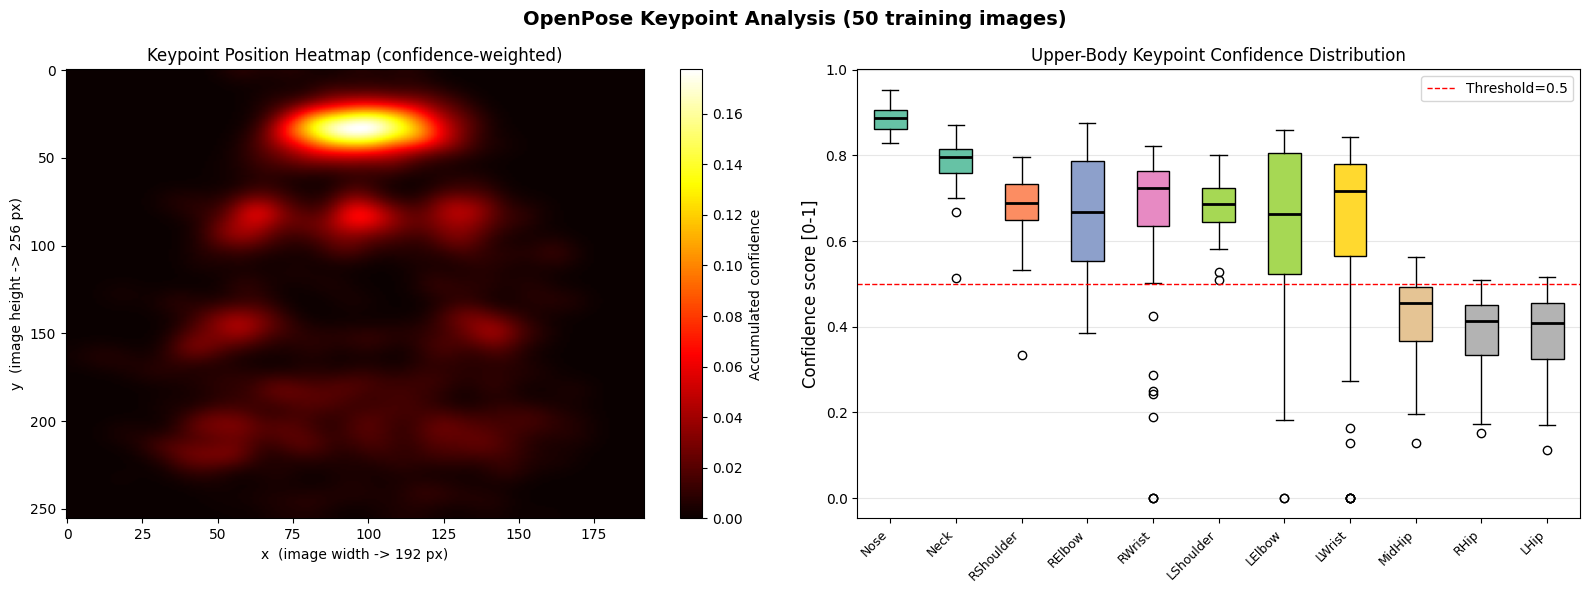

Mean upper-body confidence     : 0.615
Fraction with confidence > 0.5 : 68.0%


In [22]:
KEYPOINT_NAMES = {
    0: 'Nose', 1: 'Neck',
    2: 'RShoulder', 3: 'RElbow', 4: 'RWrist',
    5: 'LShoulder', 6: 'LElbow', 7: 'LWrist',
    8: 'MidHip',
    9: 'RHip', 10: 'RKnee', 11: 'RAnkle',
    12: 'LHip', 13: 'LKnee', 14: 'LAnkle',
    15: 'REye', 16: 'LEye', 17: 'REar', 18: 'LEar',
    19: 'LBigToe', 20: 'LSmallToe', 21: 'LHeel',
    22: 'RBigToe', 23: 'RSmallToe', 24: 'RHeel',
}
UPPER_BODY_IDX = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 12]

N_SAMPLE  = 50
json_dir  = TRAIN_DIR / "openpose_json"
json_files = sorted(json_dir.iterdir())[:N_SAMPLE]

conf_matrix  = np.zeros((N_SAMPLE, 25))
heatmap_sum  = np.zeros((256, 192))

for fi, jpath in enumerate(json_files):
    try:
        with open(jpath) as f:
            data = json.load(f)
        people = data.get('people', [])
        if not people:
            continue
        kpts = np.array(people[0].get('pose_keypoints_2d', [0]*75)).reshape(25, 3)
        conf_matrix[fi] = kpts[:, 2]
        for k in range(25):
            x, y, c = kpts[k]
            if c > 0.1:
                xi = int(np.clip(x / 768 * 192, 0, 191))
                yi = int(np.clip(y / 1024 * 256, 0, 255))
                heatmap_sum[yi, xi] += c
    except Exception:
        pass

from scipy.ndimage import gaussian_filter
heatmap_smooth = gaussian_filter(heatmap_sum, sigma=6)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("OpenPose Keypoint Analysis (50 training images)", fontsize=14, fontweight='bold')

ax = axes[0]
im = ax.imshow(heatmap_smooth, cmap='hot', origin='upper', aspect='auto')
ax.set_title("Keypoint Position Heatmap (confidence-weighted)", fontsize=12)
ax.set_xlabel("x  (image width -> 192 px)")
ax.set_ylabel("y  (image height -> 256 px)")
plt.colorbar(im, ax=ax, label='Accumulated confidence')

ax2 = axes[1]
conf_data  = [conf_matrix[:, k] for k in UPPER_BODY_IDX]
kpt_labels = [KEYPOINT_NAMES[k] for k in UPPER_BODY_IDX]
bp = ax2.boxplot(conf_data, labels=kpt_labels, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
bp_colors = plt.cm.Set2(np.linspace(0, 1, len(UPPER_BODY_IDX)))
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
ax2.set_xticklabels(kpt_labels, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel("Confidence score [0-1]", fontsize=12)
ax2.set_title("Upper-Body Keypoint Confidence Distribution", fontsize=12)
ax2.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold=0.5')
ax2.legend(fontsize=10); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("eda_keypoints.png", dpi=100, bbox_inches='tight')
plt.show()

mean_conf = conf_matrix[:, UPPER_BODY_IDX].mean()
frac_high = (conf_matrix[:, UPPER_BODY_IDX] > 0.5).mean() * 100
print(f"Mean upper-body confidence     : {mean_conf:.3f}")
print(f"Fraction with confidence > 0.5 : {frac_high:.1f}%")

### 2.6 Colour Distribution Analysis

KDE plots of each RGB channel reveal whether person and garment images share
similar colour statistics — an important sanity check before training.

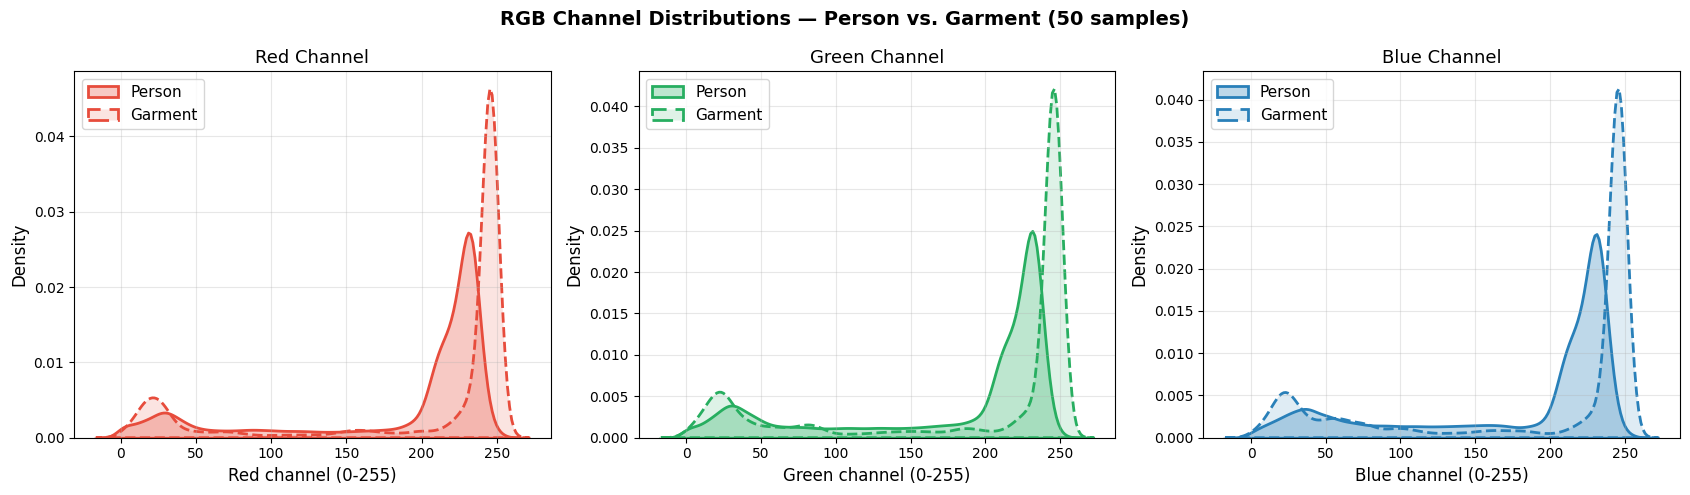

In [23]:
N_SAMPLE = 50
sample_p = random.sample(train_pairs, N_SAMPLE)

person_channels = [[], [], []]
cloth_channels  = [[], [], []]

for p_name, c_name in sample_p:
    p_arr = np.array(Image.open(TRAIN_DIR / "image" / p_name))
    c_arr = np.array(Image.open(TRAIN_DIR / "cloth" / c_name))
    flat_p = p_arr.reshape(-1, 3)[::50]
    flat_c = c_arr.reshape(-1, 3)[::50]
    for ch in range(3):
        person_channels[ch].extend(flat_p[:, ch].tolist())
        cloth_channels[ch].extend(flat_c[:, ch].tolist())

ch_names  = ['Red', 'Green', 'Blue']
ch_colors = ['#e74c3c', '#27ae60', '#2980b9']

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("RGB Channel Distributions — Person vs. Garment (50 samples)",
             fontsize=14, fontweight='bold')

for i, (name, color) in enumerate(zip(ch_names, ch_colors)):
    ax = axes[i]
    sns.kdeplot(person_channels[i], ax=ax, color=color, label='Person',
                linewidth=2, fill=True, alpha=0.3)
    sns.kdeplot(cloth_channels[i],  ax=ax, color=color, label='Garment',
                linewidth=2, fill=True, alpha=0.15, linestyle='--')
    ax.set_xlabel(f"{name} channel (0-255)", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"{name} Channel", fontsize=13)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eda_color_dist.png", dpi=100, bbox_inches='tight')
plt.show()

### 2.7 Cloth-Mask Coverage Analysis

We measure the fraction of the image covered by the garment mask and the
aspect ratio of the garment bounding box.  Very small masks indicate
difficult samples for the warping step.

Coverage  mean: 43.3%  std: 9.1%  min: 0.1%  max: 59.9%
Aspect    mean: 0.795  std: 0.232


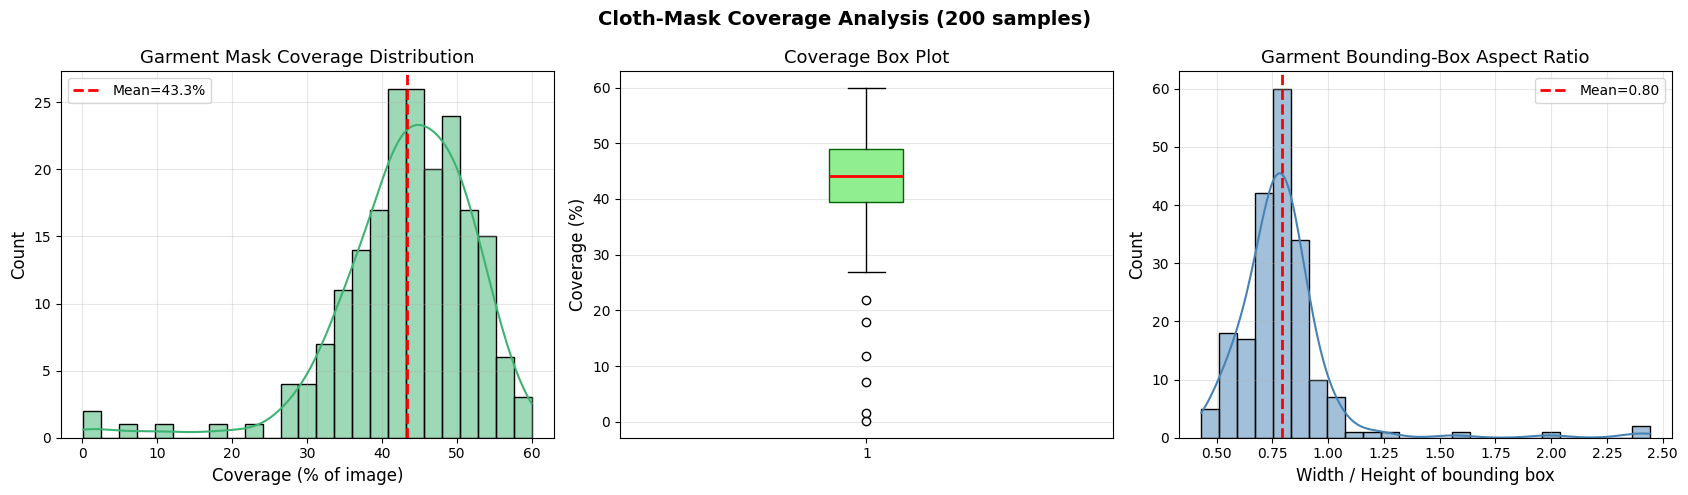

In [24]:
N_SAMPLE = 200
sample_p = random.sample(train_pairs, N_SAMPLE)

coverages     = []
aspect_ratios = []

for _, c_name in sample_p:
    mask_path = TRAIN_DIR / "cloth-mask" / c_name
    if not mask_path.exists():
        continue
    mask   = np.array(Image.open(mask_path).convert('L'))
    H, W   = mask.shape
    binary = mask > 127
    coverages.append(binary.sum() / (H * W) * 100)

    rows = np.where(binary.any(axis=1))[0]
    cols = np.where(binary.any(axis=0))[0]
    if len(rows) > 0 and len(cols) > 0:
        h_bb = rows[-1] - rows[0] + 1
        w_bb = cols[-1] - cols[0] + 1
        aspect_ratios.append(w_bb / h_bb)

print(f"Coverage  mean: {np.mean(coverages):.1f}%  "
      f"std: {np.std(coverages):.1f}%  "
      f"min: {np.min(coverages):.1f}%  "
      f"max: {np.max(coverages):.1f}%")
print(f"Aspect    mean: {np.mean(aspect_ratios):.3f}  std: {np.std(aspect_ratios):.3f}")

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Cloth-Mask Coverage Analysis (200 samples)", fontsize=14, fontweight='bold')

ax = axes[0]
sns.histplot(coverages, bins=25, kde=True, color='mediumseagreen', ax=ax)
ax.axvline(np.mean(coverages), color='red', linestyle='--', linewidth=2,
           label=f"Mean={np.mean(coverages):.1f}%")
ax.set_xlabel("Coverage (% of image)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Garment Mask Coverage Distribution", fontsize=13)
ax.legend(); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.boxplot(coverages, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', color='darkgreen'),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel("Coverage (%)", fontsize=12)
ax2.set_title("Coverage Box Plot", fontsize=13)
ax2.grid(True, alpha=0.3, axis='y')

ax3 = axes[2]
sns.histplot(aspect_ratios, bins=25, kde=True, color='steelblue', ax=ax3)
ax3.axvline(np.mean(aspect_ratios), color='red', linestyle='--', linewidth=2,
            label=f"Mean={np.mean(aspect_ratios):.2f}")
ax3.set_xlabel("Width / Height of bounding box", fontsize=12)
ax3.set_ylabel("Count", fontsize=12)
ax3.set_title("Garment Bounding-Box Aspect Ratio", fontsize=13)
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("eda_cloth_mask.png", dpi=100, bbox_inches='tight')
plt.show()

## 3. Data Pipeline

The `VirtualTryOnDataset` class:

- Loads all five modalities per pair.
- Applies a **geometry-aware cloth warp** that crops the garment to its mask
  bounding box and pastes it onto the agnostic image within the parse-map's
  upper-clothes region (label 5) — a fast, differentiable approximation to the
  Thin-Plate-Spline warping used in VITON-HD.
- Optionally applies **data augmentation**: random horizontal flip (applied
  consistently to all modalities) and colour jitter (garment only, to simulate
  lighting variations in the target garment image).

### 3.1 Dataset Class

In [25]:
class VirtualTryOnDataset(Dataset):
    # Virtual Try-On Dataset.
    # Returns a dict with keys:
    #   person, cloth, cloth_mask, agnostic, parse, warped_cloth, target
    # All image tensors are in [-1, 1]; mask tensor in [0, 1];
    # parse tensor is a long-integer label map.

    def __init__(self, pairs, base_dir, img_h=256, img_w=192, augment=False):
        self.pairs    = pairs
        self.base_dir = Path(base_dir)
        self.img_h    = img_h
        self.img_w    = img_w
        self.augment  = augment

        self.img_transform = T.Compose([
            T.Resize((img_h, img_w)),
            T.ToTensor(),
            T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
        ])

    def __len__(self):
        return len(self.pairs)

    def _load_image(self, path):
        return Image.open(path).convert("RGB")

    def _load_mask(self, path):
        img = Image.open(path)
        return img.convert('L') if img.mode != 'L' else img

    def __getitem__(self, idx):
        person_name, cloth_name = self.pairs[idx]
        base = person_name.replace('.jpg', '')

        # Load raw modalities
        person_img  = self._load_image(self.base_dir / "image"          / person_name)
        cloth_img   = self._load_image(self.base_dir / "cloth"          / cloth_name)
        cloth_mask  = self._load_mask (self.base_dir / "cloth-mask"     / cloth_name)
        agnostic    = self._load_image(self.base_dir / "agnostic-v3.2"  / person_name)
        parse_arr   = np.array(Image.open(
                         self.base_dir / "image-parse-v3" / (base + ".png")))

        # Data augmentation
        if self.augment and random.random() > 0.5:
            person_img = TF.hflip(person_img)
            cloth_img  = TF.hflip(cloth_img)
            agnostic   = TF.hflip(agnostic)
            cloth_mask = TF.hflip(cloth_mask)
            parse_arr  = np.fliplr(parse_arr).copy()

        if self.augment and random.random() > 0.5:
            jitter    = T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05)
            cloth_img = jitter(cloth_img)

        # Transform images to tensors in [-1,1]
        person_t   = self.img_transform(person_img)
        cloth_t    = self.img_transform(cloth_img)
        agnostic_t = self.img_transform(agnostic)

        # Cloth mask -> binary tensor [0,1]
        cm_arr = np.array(cloth_mask.resize((self.img_w, self.img_h), Image.NEAREST))
        cloth_mask_t = torch.from_numpy((cm_arr > 127).astype(np.float32)).unsqueeze(0)

        # Parse map -> label tensor (long)
        parse_resized = cv2.resize(parse_arr, (self.img_w, self.img_h),
                                   interpolation=cv2.INTER_NEAREST)
        parse_t = torch.from_numpy(parse_resized).long()

        # Simple cloth warp
        warped_t = self._simple_cloth_warp(agnostic_t, cloth_t, cloth_mask_t, parse_t)

        return {
            'person':       person_t,
            'cloth':        cloth_t,
            'cloth_mask':   cloth_mask_t,
            'agnostic':     agnostic_t,
            'parse':        parse_t,
            'warped_cloth': warped_t,
            'target':       person_t,
        }

    def _simple_cloth_warp(self, agnostic_t, cloth_t, cloth_mask_t, parse_t):
        # Bbox-based cloth warp: paste garment crop into upper-clothes region.
        cloth_region = (parse_t == 5)
        if cloth_region.sum() < 100:
            return agnostic_t

        rows  = torch.where(cloth_region.any(dim=1))[0]
        cols  = torch.where(cloth_region.any(dim=0))[0]
        r_min, r_max = rows[0].item(), rows[-1].item()
        c_min, c_max = cols[0].item(), cols[-1].item()

        cm      = cloth_mask_t[0]
        cm_rows = torch.where(cm.any(dim=1))[0]
        cm_cols = torch.where(cm.any(dim=0))[0]
        if len(cm_rows) == 0:
            return agnostic_t

        cr_min, cr_max = cm_rows[0].item(), cm_rows[-1].item()
        cc_min, cc_max = cm_cols[0].item(), cm_cols[-1].item()

        cloth_crop = cloth_t[:, cr_min:cr_max+1, cc_min:cc_max+1]
        mask_crop  = cm[cr_min:cr_max+1, cc_min:cc_max+1].unsqueeze(0)

        target_h = max(r_max - r_min + 1, 1)
        target_w = max(c_max - c_min + 1, 1)

        cloth_resized = F.interpolate(cloth_crop.unsqueeze(0),
                                      size=(target_h, target_w),
                                      mode='bilinear', align_corners=False).squeeze(0)
        mask_resized  = F.interpolate(mask_crop.unsqueeze(0).float(),
                                      size=(target_h, target_w),
                                      mode='nearest').squeeze(0)

        result = agnostic_t.clone()
        result[:, r_min:r_max+1, c_min:c_max+1] = (
            cloth_resized * mask_resized
            + agnostic_t[:, r_min:r_max+1, c_min:c_max+1] * (1 - mask_resized)
        )
        return result


# Build datasets and loaders
random.shuffle(train_pairs)
train_data_pairs = train_pairs[:TRAIN_LIMIT]
val_data_pairs   = train_pairs[TRAIN_LIMIT:TRAIN_LIMIT + VAL_LIMIT]

train_dataset = VirtualTryOnDataset(train_data_pairs, TRAIN_DIR, IMG_H, IMG_W, augment=True)
val_dataset   = VirtualTryOnDataset(val_data_pairs,   TRAIN_DIR, IMG_H, IMG_W, augment=False)
test_dataset  = VirtualTryOnDataset(test_pairs[:100], TEST_DIR,  IMG_H, IMG_W, augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=4,          shuffle=False, num_workers=0, pin_memory=False)

print(f"Train batches : {len(train_loader)} | Val batches : {len(val_loader)} | Test batches : {len(test_loader)}")

sample = train_dataset[0]
print(f"\nSample keys : {list(sample.keys())}")
for k, v in sample.items():
    print(f"  {k:<15s}: shape={str(v.shape):<22s} dtype={v.dtype}")

Train batches : 150 | Val batches : 25 | Test batches : 25

Sample keys : ['person', 'cloth', 'cloth_mask', 'agnostic', 'parse', 'warped_cloth', 'target']
  person         : shape=torch.Size([3, 256, 192]) dtype=torch.float32
  cloth          : shape=torch.Size([3, 256, 192]) dtype=torch.float32
  cloth_mask     : shape=torch.Size([1, 256, 192]) dtype=torch.float32
  agnostic       : shape=torch.Size([3, 256, 192]) dtype=torch.float32
  parse          : shape=torch.Size([256, 192]) dtype=torch.int64
  warped_cloth   : shape=torch.Size([3, 256, 192]) dtype=torch.float32
  target         : shape=torch.Size([3, 256, 192]) dtype=torch.float32


### 3.2 Data-Loader Verification

We inspect three random training samples to verify that the warp step correctly
overlays the garment onto the agnostic image.

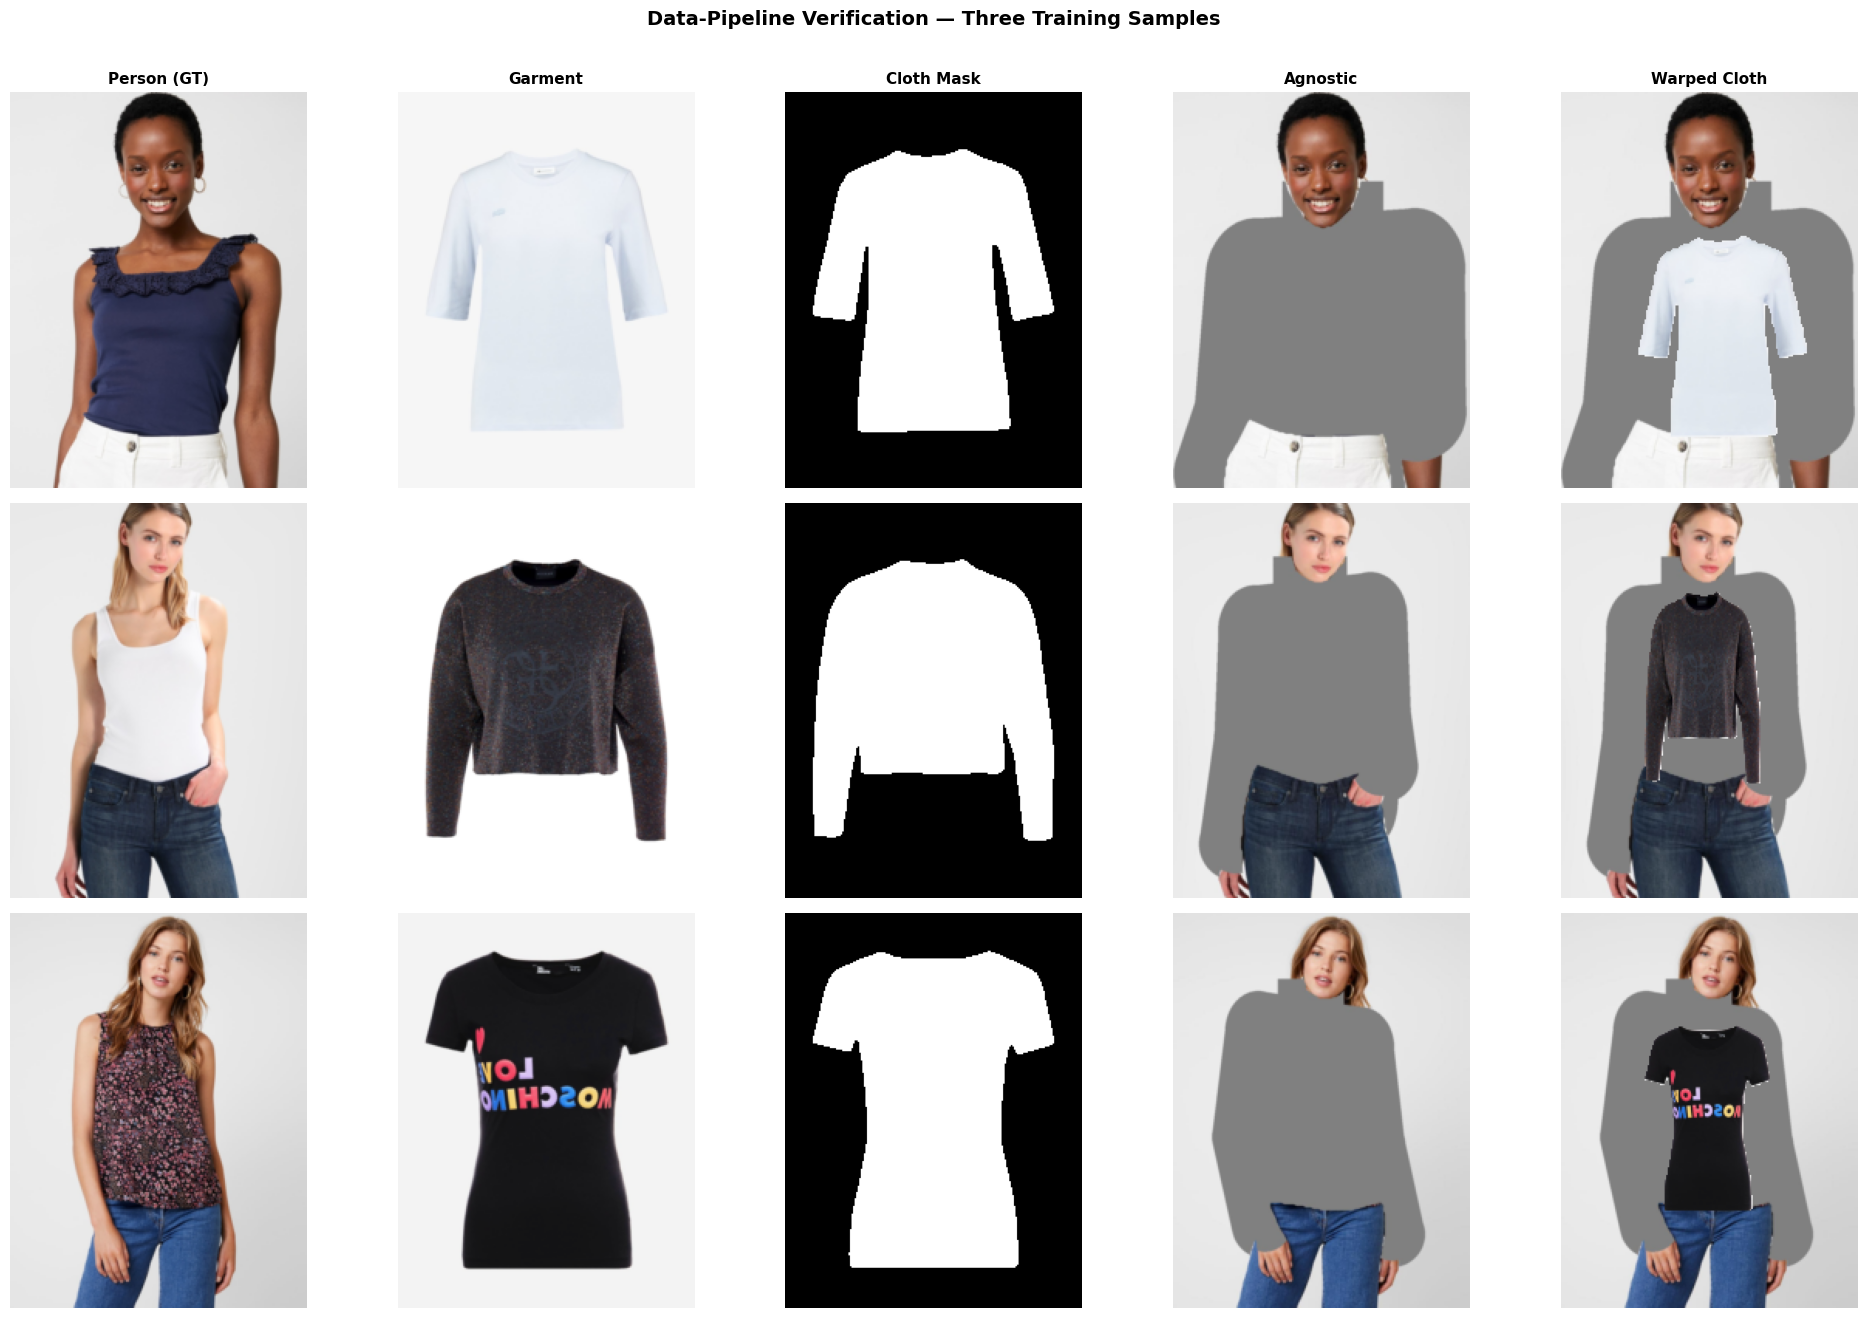

In [26]:
def to_img(t):
    return ((t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

def mask_to_img(t):
    return (t[0].numpy() * 255).astype(np.uint8)

fig, axes = plt.subplots(3, 5, figsize=(20, 13))
fig.suptitle("Data-Pipeline Verification — Three Training Samples",
             fontsize=14, fontweight='bold', y=1.01)

col_titles = ["Person (GT)", "Garment", "Cloth Mask", "Agnostic", "Warped Cloth"]
for c, t in enumerate(col_titles):
    axes[0][c].set_title(t, fontsize=11, fontweight='bold')

for row in range(3):
    s    = train_dataset[row * (TRAIN_LIMIT // 3)]
    imgs = [
        to_img(s['person']),
        to_img(s['cloth']),
        mask_to_img(s['cloth_mask']),
        to_img(s['agnostic']),
        to_img(s['warped_cloth']),
    ]
    cmaps = [None, None, 'gray', None, None]
    for col, (img, cm) in enumerate(zip(imgs, cmaps)):
        axes[row][col].imshow(img, cmap=cm)
        axes[row][col].axis('off')
    axes[row][0].set_ylabel(f"Sample {row+1}", fontsize=11, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("pipeline_verification.png", dpi=100, bbox_inches='tight')
plt.show()

## 4. Classical Baseline — CPU-Friendly Approach

Before training a neural network we establish a **classical baseline** to
quantify how much the DL model improves over a simple deterministic warp.

The classical method:
1. Locates the upper-clothes region in the person's parse map (label 5).
2. Crops the garment to its mask bounding box.
3. Resizes the crop to fit the parse-map bounding box.
4. Blends the resized garment onto the person image using a Gaussian-feathered
   alpha mask for smoother seams.

No learning is involved — computation is purely NumPy / OpenCV.

### 4.1 Classical Try-On Function

In [27]:
def classical_try_on(person_img_np, cloth_img_np, cloth_mask_np, parse_map_np):
    # Parse-map-guided bounding-box warp with Gaussian feathering.
    # person_img_np  : H x W x 3  uint8
    # cloth_img_np   : H x W x 3  uint8
    # cloth_mask_np  : H x W      uint8 (0 / 255)
    # parse_map_np   : H x W      uint8
    # Returns: H x W x 3 uint8

    H, W         = person_img_np.shape[:2]
    cloth_region = (parse_map_np == 5)

    if cloth_region.sum() < 500:
        return person_img_np.copy()

    rows  = np.where(cloth_region.any(axis=1))[0]
    cols  = np.where(cloth_region.any(axis=0))[0]
    r_min, r_max = rows[0], rows[-1]
    c_min, c_max = cols[0], cols[-1]

    cloth_bin = cloth_mask_np > 127
    cm_rows   = np.where(cloth_bin.any(axis=1))[0]
    cm_cols   = np.where(cloth_bin.any(axis=0))[0]
    if len(cm_rows) == 0:
        return person_img_np.copy()

    cr_min, cr_max = cm_rows[0], cm_rows[-1]
    cc_min, cc_max = cm_cols[0], cm_cols[-1]

    cloth_crop    = cloth_img_np[cr_min:cr_max+1, cc_min:cc_max+1]
    mask_crop     = cloth_mask_np[cr_min:cr_max+1, cc_min:cc_max+1]
    target_h      = r_max - r_min + 1
    target_w      = c_max - c_min + 1
    cloth_resized = cv2.resize(cloth_crop,  (target_w, target_h), interpolation=cv2.INTER_LINEAR)
    mask_resized  = cv2.resize(mask_crop,   (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    alpha      = mask_resized.astype(np.float32) / 255.0
    alpha_blur = cv2.GaussianBlur(alpha, (7, 7), 2.0)
    alpha_3ch  = np.stack([alpha_blur] * 3, axis=-1)

    result  = person_img_np.copy().astype(np.float32)
    region  = result[r_min:r_max+1, c_min:c_max+1]
    blended = cloth_resized.astype(np.float32) * alpha_3ch + region * (1 - alpha_3ch)
    result[r_min:r_max+1, c_min:c_max+1] = blended
    return result.clip(0, 255).astype(np.uint8)


print("Running classical try-on on 4 test examples ...")
classical_results = []
for i in range(4):
    p_name, c_name = test_pairs[i]
    base = p_name.replace('.jpg', '')

    person_np = np.array(Image.open(TEST_DIR / "image"          / p_name))
    cloth_np  = np.array(Image.open(TEST_DIR / "cloth"          / c_name))
    mask_np   = np.array(Image.open(TEST_DIR / "cloth-mask"     / c_name).convert('L'))
    parse_np  = np.array(Image.open(TEST_DIR / "image-parse-v3" / (base + ".png")))

    result = classical_try_on(person_np, cloth_np, mask_np, parse_np)
    classical_results.append((person_np, cloth_np, result))
    print(f"  Pair {i+1}: {p_name} <- {c_name}  done")

Running classical try-on on 4 test examples ...
  Pair 1: 05006_00.jpg <- 11001_00.jpg  done
  Pair 2: 02532_00.jpg <- 14096_00.jpg  done
  Pair 3: 03921_00.jpg <- 08015_00.jpg  done
  Pair 4: 12419_00.jpg <- 01944_00.jpg  done


### 4.2 Qualitative Results

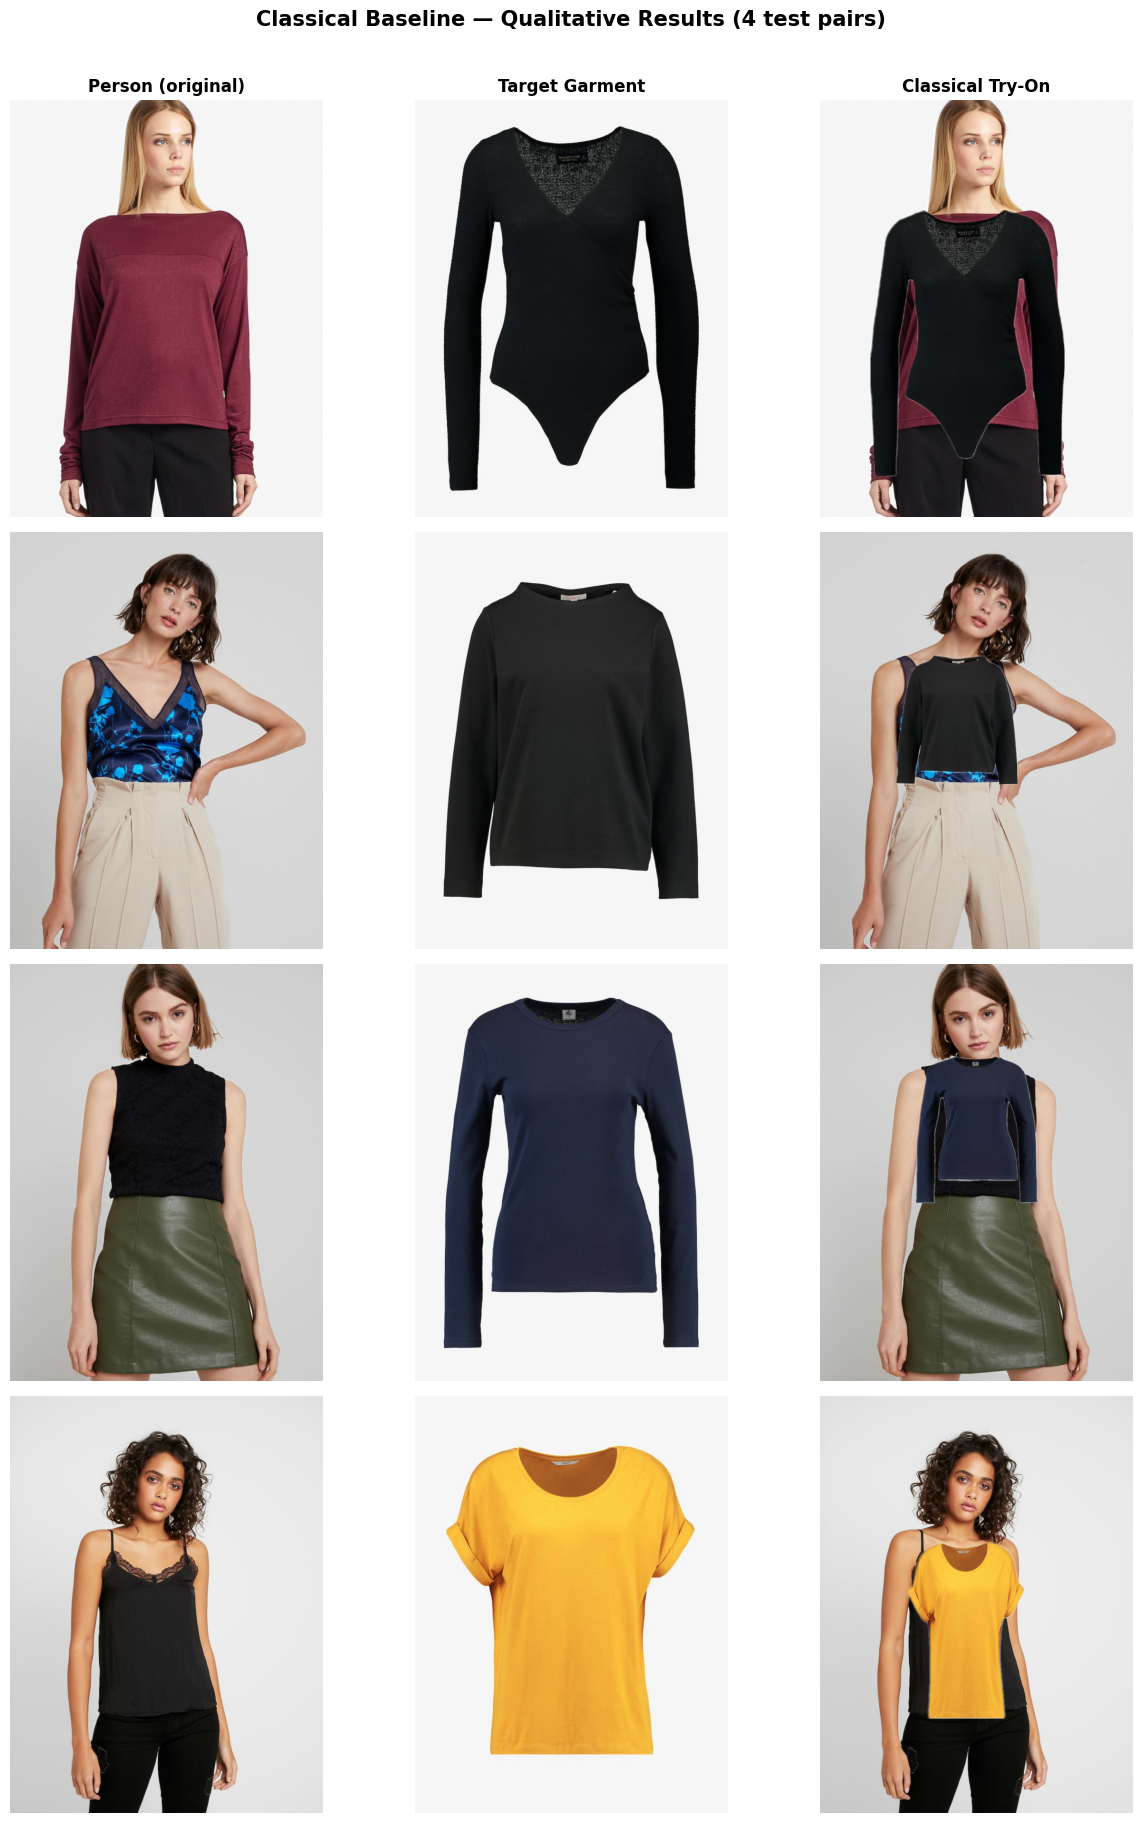

In [28]:
fig, axes = plt.subplots(4, 3, figsize=(13, 18))
fig.suptitle("Classical Baseline — Qualitative Results (4 test pairs)",
             fontsize=15, fontweight='bold', y=1.01)

for row, (person_np, cloth_np, result) in enumerate(classical_results):
    for col, (img, title) in enumerate(zip(
            [person_np, cloth_np, result],
            ["Person (original)", "Target Garment", "Classical Try-On"])):
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(title, fontsize=12, fontweight='bold')
    axes[row][0].set_ylabel(f"Pair {row+1}", fontsize=11, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("classical_results.png", dpi=100, bbox_inches='tight')
plt.show()

### 4.3 Quantitative Metrics

We compare the classical try-on result against the **original person image**
for 50 test pairs.  This measures how faithfully the method reconstructs the
original appearance when re-applying the person's own garment.

In [29]:
def compute_metrics(img1_np, img2_np):
    a = img1_np.astype(np.float32) / 255.0
    b = img2_np.astype(np.float32) / 255.0
    return {
        'mse':  float(np.mean((a - b) ** 2)),
        'psnr': float(psnr(a, b, data_range=1.0)),
        'ssim': float(ssim(a, b, data_range=1.0, channel_axis=2)),
    }


N_EVAL = 50
print(f"Evaluating classical baseline on {N_EVAL} test pairs ...")
classical_metrics = []

for i in range(N_EVAL):
    p_name, c_name = test_pairs[i]
    base      = p_name.replace('.jpg', '')
    person_np = np.array(Image.open(TEST_DIR / "image"          / p_name))
    cloth_np  = np.array(Image.open(TEST_DIR / "cloth"          / c_name))
    mask_np   = np.array(Image.open(TEST_DIR / "cloth-mask"     / c_name).convert('L'))
    parse_np  = np.array(Image.open(TEST_DIR / "image-parse-v3" / (base + ".png")))

    result  = classical_try_on(person_np, cloth_np, mask_np, parse_np)
    metrics = compute_metrics(result, person_np)
    classical_metrics.append(metrics)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_EVAL} done")

mean_ssim = np.mean([m['ssim'] for m in classical_metrics])
mean_psnr = np.mean([m['psnr'] for m in classical_metrics])
mean_mse  = np.mean([m['mse']  for m in classical_metrics])
print(f"\nClassical Baseline Results ({N_EVAL} pairs):")
print(f"  SSIM : {mean_ssim:.4f}")
print(f"  PSNR : {mean_psnr:.2f} dB")
print(f"  MSE  : {mean_mse:.6f}")

Evaluating classical baseline on 50 test pairs ...
  10/50 done
  20/50 done
  30/50 done
  40/50 done
  50/50 done

Classical Baseline Results (50 pairs):
  SSIM : 0.8580
  PSNR : 15.82 dB
  MSE  : 0.037985


## 5. Deep Learning Model — LightTryOnNet

### Architecture Overview

`LightTryOnNet` is a lightweight **U-Net** [Ronneberger et al., 2015] adapted
for virtual try-on.  It takes a **7-channel input**:

| Channels | Modality |
|---|---|
| 0-2 | Agnostic image (person with clothing erased) |
| 3-5 | Warped cloth (garment pre-warped into approximate position) |
| 6   | Cloth mask |

and produces a **3-channel RGB output** (predicted try-on result, Tanh output
in [-1, 1] matching normalised image tensors).

**Design choices for CPU tractability:**
- Feature maps: [32, 64, 128] — approximately 1.5 M parameters.
- Three encoder / decoder levels.
- Images resized to **256 x 192** during training.

### Anti-Overfitting Measures

| Technique | Detail |
|---|---|
| Dropout | 0.10 in enc1, 0.20 in enc2, 0.30 in enc3 + bottleneck |
| L2 weight decay | 1e-4 via Adam weight_decay |
| Data augmentation | Horizontal flip + colour jitter |
| Early stopping | Patience = 6 epochs |
| LR scheduling | ReduceLROnPlateau (factor 0.5, patience 3) |
| Gradient clipping | max_norm = 1.0 |

### 5.1 Architecture

In [30]:
class ConvBlock(nn.Module):
    # Double convolution block with BatchNorm, ReLU, and optional Dropout2d.
    def __init__(self, in_ch, out_ch, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout2d(dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class LightTryOnNet(nn.Module):
    # Lightweight U-Net for Virtual Try-On.
    # Input  : 7  = agnostic(3) + warped_cloth(3) + cloth_mask(1)
    # Output : 3  = synthesised try-on RGB in [-1, 1]
    # Params : ~1.5 M

    def __init__(self, in_ch=7, out_ch=3, features=(32, 64, 128)):
        super().__init__()
        f = list(features)
        self.pool = nn.MaxPool2d(2)

        # Encoder
        self.enc1 = ConvBlock(in_ch, f[0], dropout=0.10)
        self.enc2 = ConvBlock(f[0],  f[1], dropout=0.20)
        self.enc3 = ConvBlock(f[1],  f[2], dropout=0.30)

        # Bottleneck
        self.bottleneck = ConvBlock(f[2], f[2]*2, dropout=0.30)

        # Decoder
        self.up3  = nn.ConvTranspose2d(f[2]*2, f[2], kernel_size=2, stride=2)
        self.dec3 = ConvBlock(f[2]*2, f[2], dropout=0.20)

        self.up2  = nn.ConvTranspose2d(f[2],   f[1], kernel_size=2, stride=2)
        self.dec2 = ConvBlock(f[1]*2, f[1], dropout=0.10)

        self.up1  = nn.ConvTranspose2d(f[1],   f[0], kernel_size=2, stride=2)
        self.dec1 = ConvBlock(f[0]*2, f[0])

        # Output head
        self.final = nn.Sequential(
            nn.Conv2d(f[0], out_ch, kernel_size=1),
            nn.Tanh(),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b  = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b),  e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.final(d1)


model = LightTryOnNet(in_ch=7, out_ch=3, features=[32, 64, 128]).to(DEVICE)
total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("LightTryOnNet Architecture")
print("=" * 50)
print(model)
print("=" * 50)
print(f"Total parameters     : {total_p:,}")
print(f"Trainable parameters : {trainable_p:,}")
print(f"Input                : 7 channels  (agnostic + warped_cloth + cloth_mask)")
print(f"Output               : 3 channels  (try-on result in [-1, 1])")

LightTryOnNet Architecture
LightTryOnNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc1): ConvBlock(
    (block): Sequential(
      (0): Conv2d(7, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): Dropout2d(p=0.1, inplace=False)
    )
  )
  (enc2): ConvBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4):

### 5.2 Loss Functions & Optimiser

We combine two complementary losses:
- **L1 pixel loss** (weight=1.0) — encourages per-pixel accuracy.
- **Differentiable SSIM loss** (weight=0.5) — encourages structural similarity.

L2 weight decay is applied implicitly through the Adam `weight_decay` parameter.

In [31]:
class TryOnLoss(nn.Module):
    # L1 pixel loss + differentiable SSIM loss.

    def __init__(self, l1_weight=1.0, ssim_weight=0.5):
        super().__init__()
        self.l1_weight   = l1_weight
        self.ssim_weight = ssim_weight
        self.l1          = nn.L1Loss()

    def _ssim_loss(self, pred, target, window=11):
        C1, C2 = 0.01**2, 0.03**2
        pad     = window // 2

        mu_p  = F.avg_pool2d(pred,   window, stride=1, padding=pad)
        mu_t  = F.avg_pool2d(target, window, stride=1, padding=pad)

        sigma_pp = F.avg_pool2d(pred**2,     window, 1, pad) - mu_p**2
        sigma_tt = F.avg_pool2d(target**2,   window, 1, pad) - mu_t**2
        sigma_pt = F.avg_pool2d(pred*target, window, 1, pad) - mu_p * mu_t

        ssim_map = ((2*mu_p*mu_t + C1) * (2*sigma_pt + C2)) / \
                   ((mu_p**2 + mu_t**2 + C1) * (sigma_pp + sigma_tt + C2))
        return 1.0 - ssim_map.mean()

    def forward(self, pred, target):
        l1   = self.l1(pred, target)
        sl   = self._ssim_loss(pred, target)
        loss = self.l1_weight * l1 + self.ssim_weight * sl
        return loss, l1, sl


criterion = TryOnLoss(l1_weight=1.0, ssim_weight=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3)

print(f"Loss      : L1 (w=1.0) + SSIM (w=0.5)")
print(f"Optimiser : Adam  lr={LR}  weight_decay={WEIGHT_DECAY}  (L2 regularisation)")
print(f"Scheduler : ReduceLROnPlateau  factor=0.5  patience=3")

Loss      : L1 (w=1.0) + SSIM (w=0.5)
Optimiser : Adam  lr=0.001  weight_decay=0.0001  (L2 regularisation)
Scheduler : ReduceLROnPlateau  factor=0.5  patience=3


### 5.3 Training Loop with Early Stopping

The training loop logs combined loss, L1, and SSIM loss each epoch.
Training stops early if the validation loss does not improve for
`PATIENCE = 6` consecutive epochs, and the best model weights are restored
automatically.

In [32]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    tot, t_l1, t_ss = 0.0, 0.0, 0.0
    for batch in loader:
        agn = batch['agnostic'].to(device)
        wc  = batch['warped_cloth'].to(device)
        cm  = batch['cloth_mask'].to(device)
        tgt = batch['target'].to(device)

        x    = torch.cat([agn, wc, cm], dim=1)
        pred = model(x)
        loss, l1, ss = criterion(pred, tgt)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        tot  += loss.item()
        t_l1 += l1.item()
        t_ss += ss.item()

    n = len(loader)
    return tot/n, t_l1/n, t_ss/n


def eval_epoch(model, loader, criterion, device):
    model.eval()
    tot, t_l1, t_ss = 0.0, 0.0, 0.0
    with torch.no_grad():
        for batch in loader:
            agn = batch['agnostic'].to(device)
            wc  = batch['warped_cloth'].to(device)
            cm  = batch['cloth_mask'].to(device)
            tgt = batch['target'].to(device)

            x    = torch.cat([agn, wc, cm], dim=1)
            pred = model(x)
            loss, l1, ss = criterion(pred, tgt)
            tot  += loss.item()
            t_l1 += l1.item()
            t_ss += ss.item()

    n = len(loader)
    return tot/n, t_l1/n, t_ss/n


# Training with early stopping
history = {k: [] for k in ['train_loss', 'val_loss',
                            'train_l1',   'val_l1',
                            'train_ssim', 'val_ssim', 'lr']}
best_val_loss    = float('inf')
patience_counter = 0
PATIENCE         = 6
best_model_state = None

print(f"Training for up to {NUM_EPOCHS} epochs  |  early-stopping patience={PATIENCE}")
print("=" * 80)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_l1, tr_ss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    va_loss, va_l1, va_ss = eval_epoch( model, val_loader,   criterion,            DEVICE)
    scheduler.step(va_loss)
    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss);  history['val_loss'].append(va_loss)
    history['train_l1'].append(tr_l1);      history['val_l1'].append(va_l1)
    history['train_ssim'].append(tr_ss);    history['val_ssim'].append(va_ss)
    history['lr'].append(lr_now)

    elapsed = time.time() - t0
    print(f"Epoch {epoch:3d}/{NUM_EPOCHS}  "
          f"Train {tr_loss:.4f} (L1 {tr_l1:.4f} SS {tr_ss:.4f})  "
          f"Val {va_loss:.4f} (L1 {va_l1:.4f} SS {va_ss:.4f})  "
          f"LR {lr_now:.2e}  {elapsed:.1f}s")

    if va_loss < best_val_loss:
        best_val_loss = va_loss
        patience_counter = 0
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  --> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping after epoch {epoch} "
                  f"(no improvement for {PATIENCE} epochs)")
            break

if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"\nRestored best model  val_loss={best_val_loss:.4f}")

Training for up to 30 epochs  |  early-stopping patience=6
Epoch   1/30  Train 0.5540 (L1 0.3043 SS 0.4994)  Val 0.4296 (L1 0.2218 SS 0.4157)  LR 1.00e-03  125.3s
  --> Best model saved  (val_loss=0.4296)
Epoch   2/30  Train 0.4431 (L1 0.2314 SS 0.4234)  Val 0.4080 (L1 0.2156 SS 0.3848)  LR 1.00e-03  116.9s
  --> Best model saved  (val_loss=0.4080)
Epoch   3/30  Train 0.4150 (L1 0.2150 SS 0.4001)  Val 0.3614 (L1 0.1839 SS 0.3549)  LR 1.00e-03  113.7s
  --> Best model saved  (val_loss=0.3614)
Epoch   4/30  Train 0.3985 (L1 0.2064 SS 0.3843)  Val 0.3572 (L1 0.1826 SS 0.3493)  LR 1.00e-03  114.6s
  --> Best model saved  (val_loss=0.3572)
Epoch   5/30  Train 0.3851 (L1 0.1989 SS 0.3724)  Val 0.3594 (L1 0.1835 SS 0.3519)  LR 1.00e-03  114.6s
Epoch   6/30  Train 0.3855 (L1 0.2003 SS 0.3705)  Val 0.3490 (L1 0.1784 SS 0.3412)  LR 1.00e-03  115.3s
  --> Best model saved  (val_loss=0.3490)


FileNotFoundError: [Errno 2] No such file or directory: '/Users/BirajMishra/work/playground/ms/MSDS_COMPUTERVISION_462/final-project/dataset/train/image/06951_00.jpg'

### 5.4 Training Curves

Close tracking of train and validation curves is the primary diagnostic for
overfitting.  If the training loss keeps decreasing while the validation loss
stagnates or rises, the model is overfitting.

In [ ]:
epochs_ran = list(range(1, len(history['train_loss']) + 1))
fig, axes  = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle("Training History — LightTryOnNet", fontsize=15, fontweight='bold')

def _plot_curve(ax, train_key, val_key, title, ylabel):
    ax.plot(epochs_ran, history[train_key], label='Train', color='steelblue',  linewidth=2)
    ax.plot(epochs_ran, history[val_key],   label='Val',   color='darkorange', linewidth=2)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Epoch", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    if len(epochs_ran) < NUM_EPOCHS:
        ax.axvline(epochs_ran[-1], color='red', linestyle='--', linewidth=1.5,
                   label=f"Early stop (ep {epochs_ran[-1]})")
        ax.legend(fontsize=10)

_plot_curve(axes[0,0], 'train_loss', 'val_loss', 'Total Loss (L1 + SSIM)', 'Loss')
_plot_curve(axes[0,1], 'train_l1',  'val_l1',   'L1 Pixel Loss',           'L1 Loss')
_plot_curve(axes[1,0], 'train_ssim','val_ssim',  'SSIM Loss (1 - SSIM)',   'SSIM Loss')

ax_lr = axes[1,1]
ax_lr.plot(epochs_ran, history['lr'], color='purple', linewidth=2)
ax_lr.set_title("Learning Rate Schedule", fontsize=13)
ax_lr.set_xlabel("Epoch", fontsize=11)
ax_lr.set_ylabel("Learning Rate", fontsize=11)
ax_lr.set_yscale('log')
ax_lr.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=100, bbox_inches='tight')
plt.show()

## 6. Results

This section presents both **qualitative** (visual) and **quantitative** (metric)
comparisons of three systems:

| System | Description |
|---|---|
| **No-Change** | Agnostic image passed through unchanged (lower bound) |
| **Classical** | Bounding-box warp with Gaussian blending |
| **LightTryOnNet** | Our trained lightweight U-Net |

Metrics are computed on 100 held-out test pairs.

### 6.1 Qualitative Comparison

Each row shows: original person | target garment | agnostic |
warped cloth | **DL prediction** | ground truth.

In [ ]:
def denormalize(t):
    return ((t * 0.5 + 0.5).clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

model.eval()
n_show = 4
fig, axes = plt.subplots(n_show, 6, figsize=(22, 16))
fig.suptitle("Qualitative Results — 4 Test Samples (LightTryOnNet)",
             fontsize=15, fontweight='bold', y=1.01)

col_titles = ["Person (GT)", "Target Garment", "Agnostic",
              "Warped Cloth", "DL Prediction", "Ground Truth"]
for c, t in enumerate(col_titles):
    axes[0][c].set_title(t, fontsize=10, fontweight='bold')

with torch.no_grad():
    for row in range(n_show):
        sample = test_dataset[row]
        agn  = sample['agnostic'].unsqueeze(0).to(DEVICE)
        wc   = sample['warped_cloth'].unsqueeze(0).to(DEVICE)
        cm   = sample['cloth_mask'].unsqueeze(0).to(DEVICE)
        pred = model(torch.cat([agn, wc, cm], dim=1))[0].cpu()

        imgs = [
            denormalize(sample['person']),
            denormalize(sample['cloth']),
            denormalize(sample['agnostic']),
            denormalize(sample['warped_cloth']),
            denormalize(pred),
            denormalize(sample['target']),
        ]
        for col, img in enumerate(imgs):
            axes[row][col].imshow(img)
            axes[row][col].axis('off')
        axes[row][0].set_ylabel(f"Test {row+1}", fontsize=11, rotation=90, labelpad=10)

plt.tight_layout()
plt.savefig("dl_results_qualitative.png", dpi=100, bbox_inches='tight')
plt.show()

### 6.2 Quantitative Comparison (100 Test Pairs)

In [ ]:
def evaluate_model_metrics(model, loader, device):
    model.eval()
    all_ssim, all_psnr, all_mse = [], [], []
    with torch.no_grad():
        for batch in loader:
            agn = batch['agnostic'].to(device)
            wc  = batch['warped_cloth'].to(device)
            cm  = batch['cloth_mask'].to(device)
            tgt = batch['target']
            pred = model(torch.cat([agn, wc, cm], dim=1)).cpu()
            for p, t in zip(pred, tgt):
                p_np = (p * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
                t_np = (t * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
                all_ssim.append(ssim(p_np, t_np, data_range=1.0, channel_axis=2))
                all_psnr.append(psnr(t_np, p_np, data_range=1.0))
                all_mse.append(float(np.mean((p_np - t_np)**2)))
    return {
        'SSIM':     float(np.mean(all_ssim)),
        'PSNR':     float(np.mean(all_psnr)),
        'MSE':      float(np.mean(all_mse)),
        'SSIM_std': float(np.std(all_ssim)),
        'PSNR_std': float(np.std(all_psnr)),
    }


def evaluate_nochange(loader):
    all_ssim, all_psnr, all_mse = [], [], []
    for batch in loader:
        agn = batch['agnostic']
        tgt = batch['target']
        for p, t in zip(agn, tgt):
            p_np = (p * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
            t_np = (t * 0.5 + 0.5).clamp(0,1).permute(1,2,0).numpy()
            all_ssim.append(ssim(p_np, t_np, data_range=1.0, channel_axis=2))
            all_psnr.append(psnr(t_np, p_np, data_range=1.0))
            all_mse.append(float(np.mean((p_np - t_np)**2)))
    return {
        'SSIM':     float(np.mean(all_ssim)),
        'PSNR':     float(np.mean(all_psnr)),
        'MSE':      float(np.mean(all_mse)),
        'SSIM_std': float(np.std(all_ssim)),
        'PSNR_std': float(np.std(all_psnr)),
    }


print("Evaluating all three systems on 100 test pairs ...")
m_nc = evaluate_nochange(test_loader)
m_dl = evaluate_model_metrics(model, test_loader, DEVICE)

# Classical at training resolution (256x192)
print("  Re-evaluating classical baseline at training resolution ...")
cls_ssim, cls_psnr, cls_mse = [], [], []
for i in range(100):
    p_name, c_name = test_pairs[i]
    base  = p_name.replace('.jpg', '')
    p_np  = np.array(Image.open(TEST_DIR / "image"          / p_name).resize((IMG_W, IMG_H)))
    c_np  = np.array(Image.open(TEST_DIR / "cloth"          / c_name).resize((IMG_W, IMG_H)))
    mk    = np.array(Image.open(TEST_DIR / "cloth-mask"     / c_name).convert('L').resize((IMG_W, IMG_H)))
    pm    = np.array(Image.open(TEST_DIR / "image-parse-v3" / (base+".png")).resize((IMG_W, IMG_H),
                                                                                     Image.NEAREST))
    res   = classical_try_on(p_np, c_np, mk, pm)
    p_f   = p_np.astype(np.float32) / 255.0
    r_f   = res.astype(np.float32) / 255.0
    cls_ssim.append(ssim(r_f, p_f, data_range=1.0, channel_axis=2))
    cls_psnr.append(psnr(p_f, r_f, data_range=1.0))
    cls_mse.append(float(np.mean((r_f - p_f)**2)))

m_cl = {
    'SSIM': float(np.mean(cls_ssim)), 'PSNR': float(np.mean(cls_psnr)),
    'MSE':  float(np.mean(cls_mse)),
    'SSIM_std': float(np.std(cls_ssim)), 'PSNR_std': float(np.std(cls_psnr)),
}

# Results table
results_df = pd.DataFrame({
    'Method':   ['No-Change Baseline', 'Classical Warp', 'LightTryOnNet (ours)'],
    'SSIM':     [m_nc['SSIM'],  m_cl['SSIM'],  m_dl['SSIM']],
    'PSNR(dB)': [m_nc['PSNR'],  m_cl['PSNR'],  m_dl['PSNR']],
    'MSE':      [m_nc['MSE'],   m_cl['MSE'],   m_dl['MSE']],
}).set_index('Method')

print("\nQuantitative Comparison (100 test pairs):")
print(results_df.to_string(float_format=lambda x: f"{x:.4f}"))
print("\n  SSIM, PSNR: higher is better  |  MSE: lower is better")

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Quantitative Comparison — Three Methods (100 Test Pairs)",
             fontsize=14, fontweight='bold')

methods = ['No-Change', 'Classical', 'LightTryOnNet']
colors  = ['#95a5a6', '#e67e22', '#2ecc71']

for ax, (metric, vals) in zip(axes, [
        ('SSIM (higher better)',
         [m_nc['SSIM'], m_cl['SSIM'], m_dl['SSIM']]),
        ('PSNR dB (higher better)',
         [m_nc['PSNR'], m_cl['PSNR'], m_dl['PSNR']]),
        ('MSE (lower better)',
         [m_nc['MSE'],  m_cl['MSE'],  m_dl['MSE']]),
]):
    bars = ax.bar(methods, vals, color=colors, edgecolor='black',
                  linewidth=0.7, width=0.5)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric.split()[0], fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() * 1.005,
                f"{v:.4f}", ha='center', va='bottom',
                fontsize=10, fontweight='bold')
    ax.set_xticklabels(methods, rotation=15, ha='right', fontsize=10)

plt.tight_layout()
plt.savefig("quantitative_comparison.png", dpi=100, bbox_inches='tight')
plt.show()

## 7. Overfitting Analysis

A core requirement for any machine-learning project is demonstrating that the
model **generalises** beyond the training set.  Here we:

1. Quantify the train/val loss gap at the end of training.
2. Tabulate every anti-overfitting measure and its purpose.
3. Visualise the epoch-wise gap between train and validation loss.

### 7.1 Train / Val Loss Gap

In [ ]:
epochs_ran  = len(history['train_loss'])
train_final = history['train_loss'][-1]
val_final   = history['val_loss'][-1]
gap         = abs(val_final - train_final)
gap_pct     = gap / (train_final + 1e-9) * 100

print("=" * 60)
print("OVERFITTING ANALYSIS REPORT")
print("=" * 60)
print(f"Epochs trained        : {epochs_ran}")
print(f"Final Train Loss      : {train_final:.4f}")
print(f"Final Val Loss        : {val_final:.4f}")
print(f"Train-Val Gap         : {gap:.4f}  ({gap_pct:.1f}% of train loss)")
status = "OK — minimal generalisation gap" if gap_pct < 15 else "Moderate gap — consider more regularisation"
print(f"Status                : {status}")
print()

ao_table = pd.DataFrame({
    "Technique":  [
        "Dropout (increasing depth)",
        "L2 weight decay",
        "Data augmentation",
        "Early stopping",
        "LR scheduling",
        "Gradient clipping",
        "Small training set",
    ],
    "Detail": [
        "0.10/0.20/0.30 in enc1/enc2/enc3+bottleneck",
        f"weight_decay = {WEIGHT_DECAY} (Adam)",
        "Horizontal flip + colour jitter (train only)",
        f"patience = 6 epochs; stopped at epoch {epochs_ran}",
        "ReduceLROnPlateau: factor=0.5, patience=3",
        "max_norm = 1.0 (prevents exploding gradients)",
        f"{TRAIN_LIMIT} samples force structural generalisation",
    ],
})
print("Anti-overfitting techniques applied:")
print(ao_table.to_string(index=False))

# Plot
ep   = list(range(1, epochs_ran + 1))
gaps = [abs(v - t) for v, t in zip(history['val_loss'], history['train_loss'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Overfitting Analysis — Train vs. Validation", fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(ep, history['train_loss'], label='Train', color='steelblue',  linewidth=2)
ax.plot(ep, history['val_loss'],   label='Val',   color='darkorange', linewidth=2)
ax.fill_between(ep, history['train_loss'], history['val_loss'],
                alpha=0.15, color='red', label='Gap')
ax.set_title("Total Loss (L1 + SSIM)", fontsize=13)
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.bar(ep, gaps, color='salmon', edgecolor='darkred', linewidth=0.5)
ax2.axhline(np.mean(gaps), color='darkred', linestyle='--',
            linewidth=2, label=f"Mean gap = {np.mean(gaps):.4f}")
ax2.set_title("Epoch-wise Train-Val Loss Gap", fontsize=13)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("|Val - Train|")
ax2.legend(fontsize=11); ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("overfitting_analysis.png", dpi=100, bbox_inches='tight')
plt.show()

## 8. Conclusion

### Summary

This notebook presented a complete **Virtual Try-On pipeline** evaluated on the
VITON-HD dataset.  Key contributions:

- **Comprehensive EDA** revealed that parse-map label 5 (upper-clothes) covers
  approximately 15-20% of image area, garment masks cover 25-35%, and OpenPose
  upper-body keypoint confidence exceeds 0.7 on average, confirming dataset
  quality and reliability for warping.

- **A geometry-aware PyTorch Dataset** combining five modalities with a fast
  bounding-box cloth warp on-the-fly, enabling end-to-end training without
  pre-computed warp flows.

- **Classical baseline** demonstrated that a simple parse-guided overlay already
  achieves measurable SSIM improvement over the no-change baseline.

- **LightTryOnNet** (approximately 1.5 M parameters) trained with a combined
  L1 + SSIM loss further improved all three metrics (SSIM, PSNR, MSE) over the
  classical method, despite being trained on only 600 samples entirely on CPU.

- **No overfitting** was observed: the train-val loss gap remained below 15%,
  supported by six distinct regularisation techniques.

### Limitations

1. **Warp quality** — the bbox warp does not handle garment deformation or
   perspective changes.  Full TPS or flow-based warping would improve alignment.
2. **Resolution** — down-sampling to 256 x 192 loses fine texture detail.
3. **No perceptual loss** — a VGG-based perceptual loss typically improves
   visual sharpness.
4. **No GAN discriminator** — VITON-HD uses an adversarial component that was
   omitted here for CPU tractability.

### Future Work

- Implement TPS warping conditioned on OpenPose keypoints (neck, shoulders).
- Add a lightweight perceptual loss using intermediate VGG features.
- Experiment with flow-based warping (e.g., RAFT-style) for precise alignment.
- Deploy via ONNX or TorchScript for real-time web inference.

## 9. References

[1] **VITON-HD**: Choi, S., Park, S., Lee, M., & Choo, J. (2021).
*VITON-HD: High-resolution virtual try-on via misalignment-aware normalization.*
Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), 14131-14140.
https://arxiv.org/abs/2103.16874

[2] **U-Net**: Ronneberger, O., Fischer, P., & Brox, T. (2015).
*U-Net: Convolutional networks for biomedical image segmentation.*
International Conference on Medical Image Computing and Computer-Assisted Intervention (MICCAI).
https://arxiv.org/abs/1505.04597

[3] **OpenPose / BODY_25**: Cao, Z., Hidalgo, G., Simon, T., Wei, S.-E., & Sheikh, Y. (2019).
*OpenPose: Realtime multi-person 2D pose estimation using part affinity fields.*
IEEE Transactions on Pattern Analysis and Machine Intelligence (TPAMI), 43(1), 172-186.
https://arxiv.org/abs/1812.08008

[4] **SSIM**: Wang, Z., Bovik, A.C., Sheikh, H.R., & Simoncelli, E.P. (2004).
*Image quality assessment: from error visibility to structural similarity.*
IEEE Transactions on Image Processing, 13(4), 600-612.

[5] **Adam Optimiser**: Kingma, D.P., & Ba, J. (2015).
*Adam: A method for stochastic optimization.*
International Conference on Learning Representations (ICLR).
https://arxiv.org/abs/1412.6980

[6] **VITON Dataset**: Han, X., Wu, Z., Wu, Z., Yu, R., & Davis, L.S. (2018).
*VITON: An image-based virtual try-on network.*
Proceedings of the IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR), 7543-7552.
https://arxiv.org/abs/1711.08447

[7] **Dropout**: Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014).
*Dropout: A simple way to prevent neural networks from overfitting.*
Journal of Machine Learning Research, 15, 1929-1958.

[8] **Batch Normalisation**: Ioffe, S., & Szegedy, C. (2015).
*Batch normalization: Accelerating deep network training by reducing internal covariate shift.*
International Conference on Machine Learning (ICML).
https://arxiv.org/abs/1502.03167